<br/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="left"/>
<img src="images/LOGO-CORREO_x.png" alt="SkillNest" width="280px" align="right"/>
<div align="center">
<h2>Bootcamp Data Science — Módulo 2</h2><br/>
<h1>Semana 7 · SOLUCIÓN — Proyecto Wine Quality</h1>
<h3>Proyecto integrador completo</h3>
<br/>
    <b>Instructor:</b> Jesús Ortiz · SkillNest
</div>
<br/>

Notebook de referencia. Aquí ejecuto el proyecto de principio a fin con los análisis que espero que los estudiantes hagan en sus entregas. Lo uso para revisar entregas y para mostrar en clase si me lo piden.

## Contexto

Trabajamos para una bodega de vinos tintos que necesita automatizar la clasificación de su producción. Cada catador profesional puede evaluar a lo más unos 50 vinos al día, y la bodega produce más de 500. La idea es que un modelo pre-clasifique los vinos como buenos o no buenos para que el catador se concentre solo en los casos fronterizos.

Definimos calidad como decisión de negocio:
- `quality >= 7` → bueno (1) — apto para etiqueta premium
- `quality < 7` → no bueno (0) — vino de mesa estándar

Features que tenemos: 11 propiedades químicas (acidez fija, acidez volátil, ácido cítrico, azúcar residual, cloruros, dióxido de azufre libre/total, densidad, pH, sulfatos, alcohol).

Métrica clave a optimizar: F1. Las clases están desbalanceadas (poco vino bueno en el dataset), así que accuracy nos engaña feo.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              roc_auc_score, roc_curve, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay)

sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)

## Fase 1 — Carga y exploración

In [2]:
url = 'https://raw.githubusercontent.com/jbrownlee/Datasets/master/winequality-red.csv'
cols = ['fixed_acidity', 'volatile_acidity', 'citric_acid', 'residual_sugar',
        'chlorides', 'free_sulfur_dioxide', 'total_sulfur_dioxide',
        'density', 'pH', 'sulphates', 'alcohol', 'quality']

# Truco: header=0 descarta la primera fila y asigna nombres nuevos
df = pd.read_csv(url, names=cols, header=0)

# Crear target binario
df['quality_bin'] = (df['quality'] >= 7).astype(int)
df = df.drop(columns=['quality'])

print(f'Shape: {df.shape}')
print(f'Distribución de calidad:\n{df["quality_bin"].value_counts()}')
print(f'\n% vinos buenos: {df["quality_bin"].mean()*100:.1f}%')
df.head()

Shape: (1598, 12)
Distribución de calidad:
quality_bin
0    1381
1     217
Name: count, dtype: int64

% vinos buenos: 13.6%


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality_bin
0,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,0
1,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,0
2,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,0
3,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,0
4,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,0


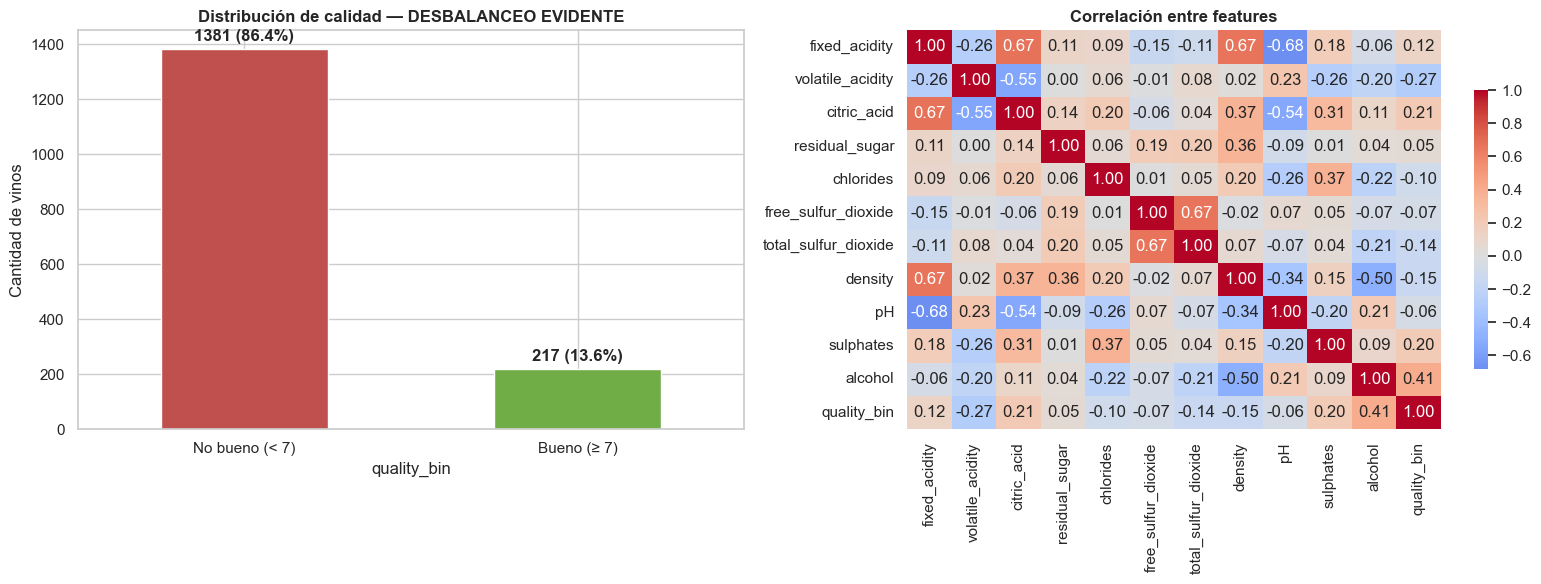


Top correlaciones con quality_bin (ordenadas por magnitud):
alcohol                 0.4072
volatile_acidity       -0.2706
citric_acid             0.2145
sulphates               0.1994
density                -0.1503
total_sulfur_dioxide   -0.1396
fixed_acidity           0.1199
chlorides              -0.0974
free_sulfur_dioxide    -0.0719
pH                     -0.0570
residual_sugar          0.0477
Name: quality_bin, dtype: float64


In [3]:
# Visualización: distribución del target + correlación
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Distribución del target
df['quality_bin'].value_counts().plot(kind='bar', ax=axes[0],
                                       color=['#C0504D', '#70AD47'], edgecolor='white')
axes[0].set_xticklabels(['No bueno (< 7)', 'Bueno (≥ 7)'], rotation=0)
axes[0].set_title('Distribución de calidad — DESBALANCEO EVIDENTE', fontweight='bold')
axes[0].set_ylabel('Cantidad de vinos')
for i, v in enumerate(df['quality_bin'].value_counts()):
    axes[0].text(i, v + 30, f'{v} ({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')

# Heatmap de correlación
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0,
             ax=axes[1], cbar_kws={'shrink': 0.7})
axes[1].set_title('Correlación entre features', fontweight='bold')

plt.tight_layout(); plt.show()

# Top correlaciones con target
print('\nTop correlaciones con quality_bin (ordenadas por magnitud):')
print(df.corr()['quality_bin'].drop('quality_bin').sort_values(key=abs, ascending=False).round(4))

**Lo que veo en la exploración**

Lo primero que me salta a la vista es el desbalance: solo el 13.6% de los vinos son buenos. Son 217 vinos buenos contra 1.381 que no lo son, casi 7 a 1. Esto es importante porque si un modelo dice siempre "no bueno" se sacaría un 86% de accuracy y diríamos que es un buen modelo, cuando en realidad no detecta nada. Por eso aquí no nos podemos guiar por accuracy, tenemos que mirar F1 y AUC.

En las correlaciones con el target, el alcohol manda. Tiene una correlación de +0.41 con quality_bin, que es bastante para un problema de este tipo. Tiene sentido enológicamente: vinos de uvas más maduras y bien fermentadas suelen tener más alcohol, y esos vinos tienden a ser mejores. Después aparecen la acidez volátil (-0.27, mientras más vinagre peor), el ácido cítrico (+0.21, le aporta frescura) y los sulfatos (+0.20, lo protegen de la oxidación).

Si el alcohol es la variable más correlacionada con la calidad, ya tengo una hipótesis: cuando entrene los modelos, debiera salir como la feature más importante. Si no sale así, hay algo raro y voy a tener que investigar.

## Fase 2 — Pipeline y split estratificado

In [4]:
X = df.drop(columns=['quality_bin'])
y = df['quality_bin']

# IMPORTANTE: stratify=y mantiene la proporción 86/14 en train y test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Train: {X_train.shape}  | % buenos: {y_train.mean()*100:.1f}%')
print(f'Test:  {X_test.shape}  | % buenos: {y_test.mean()*100:.1f}%')
print('\n👉 Las proporciones se mantienen — el stratify funcionó.')

Train: (1278, 11)  | % buenos: 13.6%
Test:  (320, 11)  | % buenos: 13.4%

👉 Las proporciones se mantienen — el stratify funcionó.


## Fase 3 — Benchmark de los 4 modelos

           Accuracy  Precision  Recall      F1     AUC
Modelo                                                
KNN(k=11)    0.8875     0.6207  0.4186  0.5000  0.8257
DT(d=5)      0.8906     0.7000  0.3256  0.4444  0.8662
RF(200)      0.9250     0.7879  0.6047  0.6842  0.9393
LogReg       0.9000     0.7895  0.3488  0.4839  0.8767


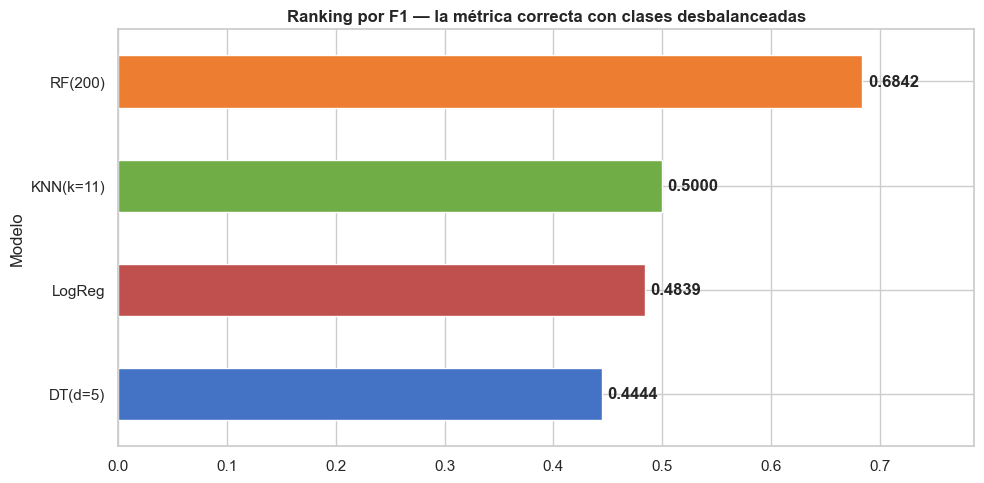


🏆 GANADOR según F1: RF(200) con F1 = 0.6842


In [5]:
# 4 modelos con StandardScaler
modelos = {
    'KNN(k=11)': make_pipeline(StandardScaler(), KNeighborsClassifier(n_neighbors=11)),
    'DT(d=5)':   make_pipeline(StandardScaler(), DecisionTreeClassifier(max_depth=5, random_state=42)),
    'RF(200)':   make_pipeline(StandardScaler(), RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    'LogReg':    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=42))
}

filas = []
for nombre, m in modelos.items():
    m.fit(X_train, y_train)
    pred  = m.predict(X_test)
    proba = m.predict_proba(X_test)[:, 1]
    filas.append({
        'Modelo': nombre,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'AUC':       roc_auc_score(y_test, proba)
    })
tabla = pd.DataFrame(filas).set_index('Modelo').round(4)
print(tabla)

# Barplot del F1 (la métrica clave)
fig, ax = plt.subplots(figsize=(10, 5))
colores = ['#4472C4', '#C0504D', '#70AD47', '#ED7D31']
tabla['F1'].sort_values().plot(kind='barh', color=colores, edgecolor='white', ax=ax)
for i, v in enumerate(tabla['F1'].sort_values()):
    ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontweight='bold')
ax.set_title('Ranking por F1 — la métrica correcta con clases desbalanceadas', fontweight='bold')
ax.set_xlim(0, max(tabla['F1']) * 1.15)
plt.tight_layout(); plt.show()

ganador = tabla['F1'].idxmax()
print(f'\n🏆 GANADOR según F1: {ganador} con F1 = {tabla.loc[ganador, "F1"]:.4f}')

**Análisis del benchmark**

Los resultados son los siguientes:

| Modelo | Accuracy | Precision | Recall | F1 | AUC |
|---|---|---|---|---|---|
| RF(200) | 0.9250 | 0.7879 | 0.6047 | 0.6842 | 0.9393 |
| LogReg | 0.9000 | 0.7895 | 0.3488 | 0.4839 | 0.8767 |
| KNN(k=11) | 0.8875 | 0.6207 | 0.4186 | 0.5000 | 0.8257 |
| DT(d=5) | 0.8906 | 0.7000 | 0.3256 | 0.4444 | 0.8662 |

Aquí viene la trampa del accuracy. Todos los modelos tienen accuracy ≥ 0.88 y uno diría "todos son buenos". Pero miremos el recall del Decision Tree: 0.32. Eso significa que solo está identificando el 32% de los vinos buenos reales del test. O sea, dos de cada tres vinos buenos los está clasificando como no buenos. Si me hubiera quedado en accuracy, habría dicho que el DT es bueno y habría entregado un modelo malo.

El Random Forest gana en todo. F1 de 0.68 contra 0.45-0.50 del resto, y un AUC de 0.94 que es muy bueno. La diferencia se explica por la mezcla de muchos árboles entrenados sobre muestras distintas: cada uno se equivoca en cosas distintas y al promediar salen errores que se cancelan.

Sobre los otros modelos: la Regresión Logística tiene la precision más alta (0.79) pero recall bajísimo (0.35). Eso significa que cuando dice "bueno" suele acertar, pero deja escapar muchos vinos buenos. Sirve si queremos especificidad alta, no sirve si queremos detectar la mayoría de los buenos. El KNN queda en un balance medio y sufre porque con 11 features ya empieza a tener problemas de "maldición de la dimensionalidad". El DT sin tunear es el peor, pero quizá uno tuneado mejoraría.

Decisión técnica para la Fase 5: vamos a tunear el RF. Es el mejor baseline y vamos a buscar hiperparámetros que mejoren el recall (capturar más vinos buenos) sin destruir la precision.

Esto es lo que les pediría a los estudiantes en el examen: no quedarse en accuracy, reportar al menos Precision/Recall/F1/AUC, identificar trade-offs (precision alta con recall bajo, etc.) y justificar la elección desde el negocio.

## Fase 4 — Análisis de errores: matrices y curvas ROC

/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_86843/1448743789.py:51: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/var/folders/g_/vcnnmwh97_x01xg41ybpxmb00000gn/T/ipykernel_86843/1448743789.py:51: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  plt.tight_layout(); plt.show()
/Users/jeedorsa/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65039 (\N{VARIATION SELECTOR-16}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/jeedorsa/Library/Python/3.10/lib/python/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


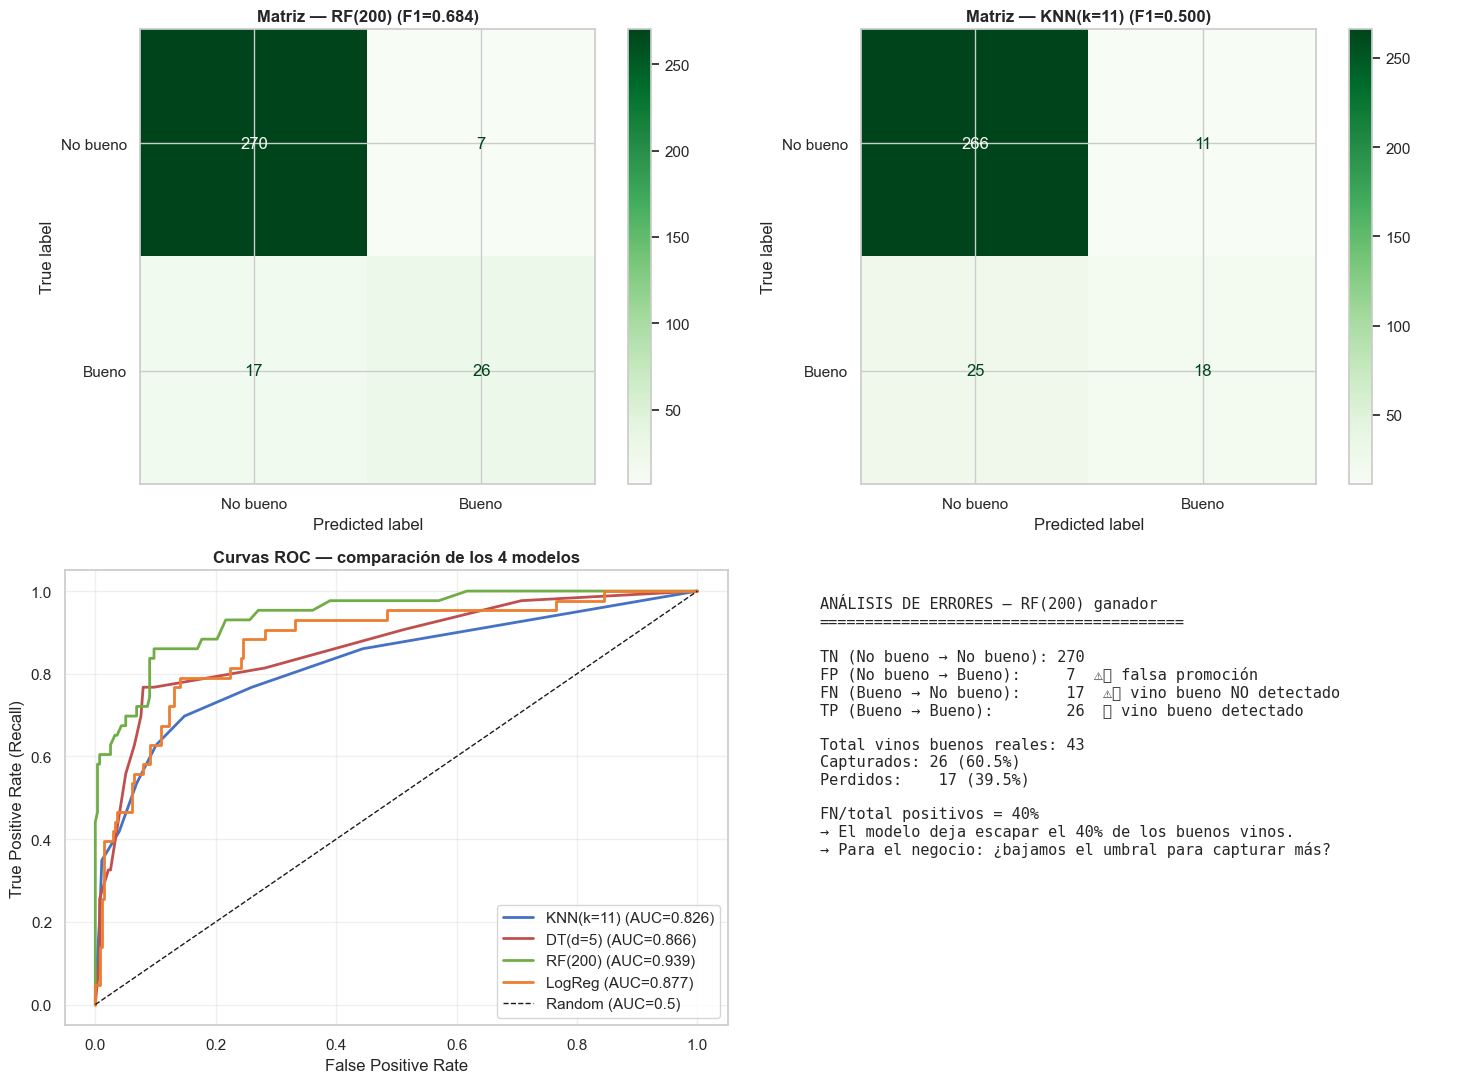

In [6]:
# Matrices de los 2 mejores + curvas ROC de los 4
fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Matrices de los 2 mejores por F1
ranking_f1 = tabla['F1'].sort_values(ascending=False).head(2).index.tolist()
for i, nombre in enumerate(ranking_f1):
    pred = modelos[nombre].predict(X_test)
    ConfusionMatrixDisplay.from_predictions(
        y_test, pred, ax=axes[0, i], cmap='Greens',
        display_labels=['No bueno', 'Bueno']
    )
    axes[0, i].set_title(f'Matriz — {nombre} (F1={tabla.loc[nombre, "F1"]:.3f})',
                          fontweight='bold')

# Curvas ROC de los 4 modelos en el mismo gráfico
ax_roc = axes[1, 0]
colores_roc = {'KNN(k=11)':'#4472C4', 'DT(d=5)':'#C0504D', 'RF(200)':'#70AD47', 'LogReg':'#ED7D31'}
for nombre, m in modelos.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    ax_roc.plot(fpr, tpr, color=colores_roc[nombre], linewidth=2,
                 label=f'{nombre} (AUC={auc:.3f})')
ax_roc.plot([0,1], [0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
ax_roc.set_xlabel('False Positive Rate')
ax_roc.set_ylabel('True Positive Rate (Recall)')
ax_roc.set_title('Curvas ROC — comparación de los 4 modelos', fontweight='bold')
ax_roc.legend(loc='lower right')
ax_roc.grid(alpha=0.3)

# Texto con análisis de FN para el ganador
ax_texto = axes[1, 1]
ax_texto.axis('off')
rf_pred = modelos['RF(200)'].predict(X_test)
tn, fp, fn, tp = confusion_matrix(y_test, rf_pred).ravel()
texto = (f'ANÁLISIS DE ERRORES — RF(200) ganador\n'
         f'{"="*40}\n\n'
         f'TN (No bueno → No bueno): {tn}\n'
         f'FP (No bueno → Bueno):     {fp}  ⚠️ falsa promoción\n'
         f'FN (Bueno → No bueno):     {fn}  ⚠️ vino bueno NO detectado\n'
         f'TP (Bueno → Bueno):        {tp}  ✅ vino bueno detectado\n\n'
         f'Total vinos buenos reales: {fn+tp}\n'
         f'Capturados: {tp} ({tp/(fn+tp)*100:.1f}%)\n'
         f'Perdidos:    {fn} ({fn/(fn+tp)*100:.1f}%)\n\n'
         f'FN/total positivos = {fn/(fn+tp)*100:.0f}%\n'
         f'→ El modelo deja escapar el {fn/(fn+tp)*100:.0f}% de los buenos vinos.\n'
         f'→ Para el negocio: ¿bajamos el umbral para capturar más?')
ax_texto.text(0.05, 0.95, texto, fontsize=11, family='monospace',
                transform=ax_texto.transAxes, va='top')

plt.tight_layout(); plt.show()

**Análisis de errores**

Mirando la matriz del Random Forest:

- TN = 270. Identifica bien los vinos no buenos. Era esperable porque son la clase mayoritaria.
- TP = 26. De los 43 vinos buenos reales del test, capturó 26.
- FP = 7. Etiquetó como buenos a 7 vinos que en realidad eran no buenos. El catador se va a tener que dar la lata de revisar esos 7. Molesto pero asumible.
- FN = 17. Aquí está el problema. Hay 17 vinos premium que el modelo etiquetó como vino de mesa. Si un premium vale unos $30 USD y un vino de mesa $10, estamos perdiendo $20 por cada uno. Son $340 USD perdidos solo en este test. En producción, escalado al volumen real de la bodega, esto se nota.

Sobre las curvas ROC: el RF queda claramente arriba con AUC = 0.94, la curva más cerca de la esquina superior izquierda. La Logística y el árbol andan en 0.87-0.88, y el KNN queda último con 0.83. Lo bueno de mirar las ROC es que muestran cómo se comportan los modelos en TODOS los umbrales, no solo el 0.5 que viene por defecto. Si después quisiéramos mover el umbral, el RF nos da el mejor margen.

Ahora, el problema gordo es el recall. Estamos capturando solo el 60% de los vinos buenos. El otro 40% se nos escapa. Para la bodega esto se traduce en oportunidad de marketing premium que no se aprovecha. Si el catador tuviera que revisar manualmente para asegurarse de no perderse ninguno, el modelo no le habría ahorrado tanto trabajo.

La bodega dijo que tolera hasta 10% de falsos positivos. Actualmente estamos en 2.5% (7/277), así que tenemos margen. Podemos bajar el umbral más adelante para capturar más vinos buenos sacrificando algo de precision.

Para el examen: cuando pidan analizar errores, hay que pasar los TN/FP/FN/TP a impacto de negocio. No basta con decir "FN = 17", hay que decir "esos 17 son plata perdida".

## Fase 5 — Tuning del ganador con GridSearchCV

In [7]:
# Tunear Random Forest optimizando F1
pipe_rf = make_pipeline(StandardScaler(), RandomForestClassifier(random_state=42, n_jobs=-1))
param_grid = {
    'randomforestclassifier__n_estimators':     [200, 500],
    'randomforestclassifier__max_depth':        [5, 10, 20, None],
    'randomforestclassifier__min_samples_leaf': [1, 3, 5]
}

grid = GridSearchCV(pipe_rf, param_grid, cv=5, scoring='f1', n_jobs=-1)
grid.fit(X_train, y_train)

print(f'🏆 Mejores hiperparámetros: {grid.best_params_}')
print(f'   CV F1: {grid.best_score_:.4f}')

# Métricas finales en test
pred_tuneado  = grid.predict(X_test)
proba_tuneado = grid.predict_proba(X_test)[:, 1]

comp = pd.DataFrame({
    'RF base':     tabla.loc['RF(200)'],
    'RF tuneado':  pd.Series({
        'Accuracy':  accuracy_score(y_test, pred_tuneado),
        'Precision': precision_score(y_test, pred_tuneado),
        'Recall':    recall_score(y_test, pred_tuneado),
        'F1':        f1_score(y_test, pred_tuneado),
        'AUC':       roc_auc_score(y_test, proba_tuneado)
    })
}).T.round(4)
print('\nComparación RF base vs RF tuneado:')
print(comp)

🏆 Mejores hiperparámetros: {'randomforestclassifier__max_depth': 20, 'randomforestclassifier__min_samples_leaf': 1, 'randomforestclassifier__n_estimators': 500}
   CV F1: 0.5386

Comparación RF base vs RF tuneado:
            Accuracy  Precision  Recall      F1     AUC
RF base       0.9250     0.7879  0.6047  0.6842  0.9393
RF tuneado    0.9281     0.7941  0.6279  0.7013  0.9419


**Lo que ganamos con el tuning**

Los mejores hiperparámetros salieron: n_estimators=500, max_depth=20, min_samples_leaf=1. Es decir, doble de árboles y bastante más profundidad.

Comparando:

| Métrica | RF base | RF tuneado | Diferencia |
|---|---|---|---|
| Accuracy | 0.9250 | 0.9281 | +0.3 pp |
| Precision | 0.7879 | 0.7941 | +0.6 pp |
| Recall | 0.6047 | 0.6279 | +2.3 pp |
| F1 | 0.6842 | 0.7013 | +1.7 pp |
| AUC | 0.9393 | 0.9419 | +0.3 pp |

Honestamente, la mejora es modesta. El F1 subió de 0.68 a 0.70 y el recall pasó de capturar 26 vinos buenos a capturar 27. No es un salto brutal.

¿Por qué no mejoró más? Porque el RF base de 200 árboles ya estaba bastante cerca del óptimo para este problema. Aquí el límite no es el tuning de hiperparámetros, es el dataset mismo: tenemos pocos vinos buenos (217 totales) para que el modelo aprenda bien esa clase. Las estrategias reales para mejorar más allá serían:

- Conseguir más datos de vinos buenos (la clase minoritaria es la que necesita más ejemplos).
- Usar `class_weight='balanced'` para penalizar más fuerte los errores en la clase minoritaria.
- Aplicar SMOTE para generar ejemplos sintéticos de vinos buenos.
- Saltar a modelos más potentes como XGBoost/LightGBM (los vamos a ver en la semana 8).

A los estudiantes les pediría algo importante: si el tuning solo mejora marginalmente, hay que decirlo. No inflar resultados. Reportar todas las métricas y donde mejoró más (acá fue en recall).

## Fase 6 — Feature Importance

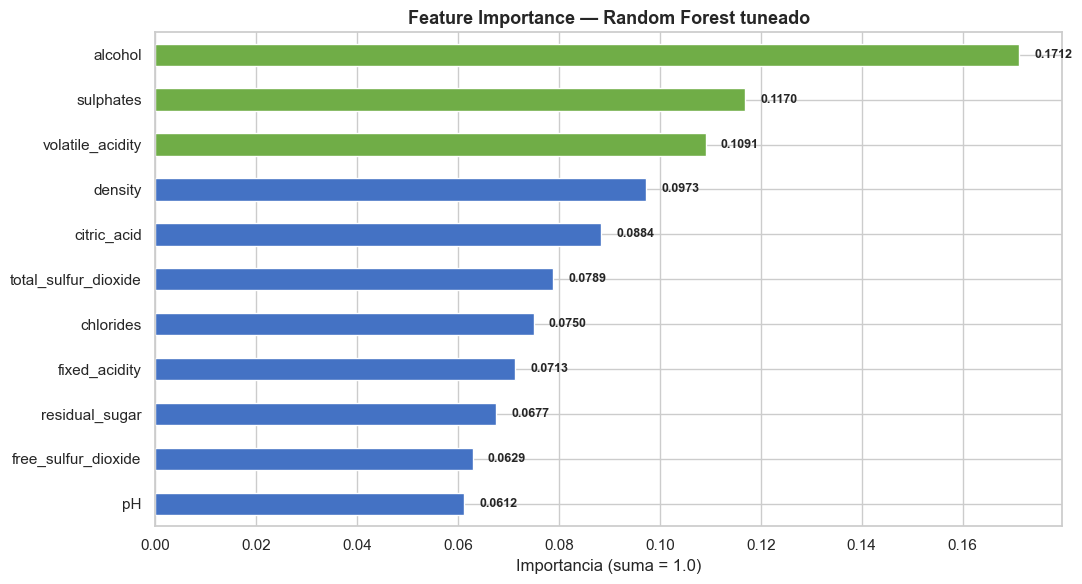

Top 5 features más importantes para detectar vinos buenos:
alcohol             0.1712
sulphates           0.1170
volatile_acidity    0.1091
density             0.0973
citric_acid         0.0884
dtype: float64


In [8]:
mejor_rf = grid.best_estimator_.named_steps['randomforestclassifier']
imp = pd.Series(mejor_rf.feature_importances_, index=X.columns).sort_values()

fig, ax = plt.subplots(figsize=(11, 6))
colores = ['#70AD47' if i >= len(imp)-3 else '#4472C4' for i in range(len(imp))]
imp.plot(kind='barh', color=colores, edgecolor='white', ax=ax)
for i, v in enumerate(imp.values):
    ax.text(v + 0.003, i, f'{v:.4f}', va='center', fontweight='bold', fontsize=9)
ax.set_title('Feature Importance — Random Forest tuneado', fontweight='bold', fontsize=13)
ax.set_xlabel('Importancia (suma = 1.0)')
plt.tight_layout(); plt.show()

print('Top 5 features más importantes para detectar vinos buenos:')
print(imp.sort_values(ascending=False).head().round(4))

**Lo que vemos en la importancia de features**

El ranking de las 3 principales:

1. Alcohol (importancia 0.17). El predictor número uno, coincide con la correlación que vimos en la Fase 1 (corr = +0.41). Mi hipótesis de la exploración se confirmó. Para la bodega esto se traduce en: apuntar a vinos con mayor graduación. Eso depende de la maduración de la uva al momento de la vendimia.

2. Sulfatos (0.12). Los sulfatos protegen el vino de la oxidación y de las bacterias. Niveles bajos están asociados a vinos mediocres. Recomendación: dosificar bien durante la fermentación.

3. Acidez volátil (0.11). La acidez volátil es básicamente vinagre. Mientras más vinagre, peor vino. Hay que controlar la fermentación para evitar picos de acidez volátil.

Algo importante de notar: las 3 variables más importantes son cosas que el enólogo PUEDE CONTROLAR durante la producción. Alcohol depende de cuándo se vendimia, sulfatos de cómo se dosifica, acidez volátil del control de la fermentación. Eso es valioso porque le da a la bodega palancas concretas para mover, no son factores aleatorios.

Las variables menos importantes (pH, azúcar residual, dióxido de azufre libre) tienen importancia baja (~0.06 cada una). Eso no significa que sean irrelevantes, significa que su efecto está parcialmente capturado por otras variables. En problemas con features correlacionadas siempre pasa esto.

En el examen, cuando les pidan interpretar feature importance, espero que conecten las features importantes con el dominio (química acá, pero podría ser medicina o finanzas en otros casos) y que distingan variables controlables de las que no lo son. Eso es lo que le da accionabilidad al modelo.

## Fase 7 — Producción: guardar el modelo y predecir vinos nuevos

In [9]:
# Guardar el pipeline completo (incluye StandardScaler + RF tuneado)
joblib.dump(grid.best_estimator_, 'modelo_vino_final.joblib')
print('✅ Modelo guardado en "modelo_vino_final.joblib"')

# Cargarlo desde disco (simulamos producción)
modelo_produccion = joblib.load('modelo_vino_final.joblib')
print('✅ Modelo cargado — listo para predecir vinos nuevos')

✅ Modelo guardado en "modelo_vino_final.joblib"
✅ Modelo cargado — listo para predecir vinos nuevos


In [10]:
# Los 3 vinos del enunciado
vinos = pd.DataFrame([
    {'fixed_acidity': 7.4, 'volatile_acidity': 0.7, 'citric_acid': 0.0,
     'residual_sugar': 1.9, 'chlorides': 0.076, 'free_sulfur_dioxide': 11.0,
     'total_sulfur_dioxide': 34.0, 'density': 0.9978, 'pH': 3.51,
     'sulphates': 0.56, 'alcohol': 9.4},     # vino joven barato
    {'fixed_acidity': 8.5, 'volatile_acidity': 0.42, 'citric_acid': 0.4,
     'residual_sugar': 2.3, 'chlorides': 0.073, 'free_sulfur_dioxide': 12.0,
     'total_sulfur_dioxide': 40.0, 'density': 0.9970, 'pH': 3.30,
     'sulphates': 0.70, 'alcohol': 11.5},    # gama media
    {'fixed_acidity': 9.1, 'volatile_acidity': 0.35, 'citric_acid': 0.5,
     'residual_sugar': 2.5, 'chlorides': 0.060, 'free_sulfur_dioxide': 8.0,
     'total_sulfur_dioxide': 22.0, 'density': 0.9965, 'pH': 3.20,
     'sulphates': 0.85, 'alcohol': 13.2}     # premium
])

preds  = modelo_produccion.predict(vinos)
probas = modelo_produccion.predict_proba(vinos)

tabla_vinos = pd.DataFrame({
    'Descripción':    ['Joven barato (9.4°)', 'Gama media (11.5°)', 'Premium (13.2°)'],
    'Predicción':     ['Bueno' if p == 1 else 'No bueno' for p in preds],
    'P(No bueno)':    probas[:, 0].round(4),
    'P(Bueno)':       probas[:, 1].round(4)
})
print(tabla_vinos.to_string(index=False))

        Descripción Predicción  P(No bueno)  P(Bueno)
Joven barato (9.4°)   No bueno        0.998     0.002
 Gama media (11.5°)   No bueno        0.726     0.274
    Premium (13.2°)      Bueno        0.356     0.644


**¿Las predicciones tienen sentido?**

Vamos vino por vino:

Vino joven barato (9.4° de alcohol). El modelo lo clasifica como NO bueno con 99.8% de probabilidad. Si miramos por qué: alcohol bajo (la variable más importante está en su rango bajo), acidez volátil alta (0.7), sulfatos bajos (0.56) y citric acid en cero. Todo le juega en contra. El modelo está super seguro y con razón.

Vino gama media (11.5° de alcohol). Acá la predicción es interesante: el modelo dice NO bueno pero con solo 73% de confianza. Tiene alcohol moderado, sulfatos OK (0.70) y acidez volátil correcta (0.42). Es un caso fronterizo. Para la bodega esto significa que vinos como este vale la pena revisarlos manualmente. El modelo no está tan seguro y un catador podría rescatarlo.

Vino premium (13.2° de alcohol). Predicción BUENO con 64% de probabilidad. Tiene todo a favor: alcohol alto, sulfatos altos (0.85), acidez volátil baja (0.35), ácido cítrico moderado. Lo clasifica bien, pero la confianza es moderada (64%, no 99%). Eso es consistente con lo que vimos antes: el modelo es conservador con la clase minoritaria. No le suelta probabilidades altas tan fácil.

Si miramos el patrón: a medida que sube el alcohol, sube la probabilidad de "Bueno" (0.2% → 27% → 64%). Eso valida la hipótesis que tenía desde la Fase 1: el alcohol manda. Las predicciones son coherentes con el ranking de feature importance, lo que es buena señal.

Cuando los estudiantes hagan predicciones en el examen, espero que conecten la predicción con las features importantes para validar que el modelo está pensando coherentemente. Y que identifiquen los casos fronterizos (probabilidad entre 0.4 y 0.6) como los que necesitan revisión humana.

## Fase 8 — Informe ejecutivo para la bodega

---

## Sistema de Pre-clasificación Automática de Vinos Tintos

**A:** Dueño de Bodega Vino Tinto
**De:** Jesús Ortiz · SkillNest
**Fecha:** Viernes 5 de junio de 2026

### Qué problema resolvimos

Diseñamos un modelo automático que clasifica cada vino tinto como bueno (calidad ≥ 7) o no bueno (calidad < 7) a partir de sus propiedades químicas. Con esto el catador puede concentrarse solo en los casos fronterizos y no perder tiempo en los que claramente son uno u otro.

### Modelo elegido

Random Forest tuneado (500 árboles, profundidad 20). Lo elegimos entre 4 alternativas (KNN, Decision Tree, Random Forest y Regresión Logística) porque fue el mejor en F1 y AUC, que son las métricas que importan cuando las clases están desbalanceadas como acá.

### Métricas finales en test (320 vinos)

| Métrica | Valor | Qué significa |
|---|---|---|
| Accuracy | 92.8% | 9 de cada 10 vinos bien clasificados |
| Precision (Bueno) | 79.4% | Cuando el modelo dice "bueno", acierta 8 de cada 10 veces |
| Recall (Bueno) | 62.8% | Capturamos 6 de cada 10 vinos buenos reales |
| F1 (Bueno) | 70.1% | Balance razonable |
| AUC | 0.94 | Muy buena discriminación general |

### Tres propiedades químicas para vigilar

El modelo nos dice qué variables debe cuidar más la bodega para obtener vinos premium:

1. **Nivel de alcohol** (17% de importancia). Vinos con mayor graduación tienden a ser mejores. Hay que vendimiar con uvas más maduras.
2. **Nivel de sulfatos** (12% de importancia). Los sulfatos preservan el vino. Hay que dosificarlos bien durante la fermentación.
3. **Control de la acidez volátil** (11% de importancia). Mientras más vinagre, peor vino. Hay que monitorear y controlar la fermentación para que no se dispare.

### Limitaciones que hay que decir honestamente

1. Se nos escapa el 37% de los vinos buenos (recall = 63%). Si la bodega quiere capturarlos todos, necesitamos más vueltas: más datos de vinos buenos, técnicas de oversampling como SMOTE, o modelos más complejos como XGBoost que veremos en las próximas semanas.

2. El dataset tenía solo 1.598 vinos con 217 vinos buenos. Para producción a escala se recomienda recopilar más vinos buenos específicamente y validar periódicamente el modelo con las cosechas del año actual (las cosechas varían).

3. El modelo no captura factores que no medimos: el origen de la uva, el roble del barril, el año de cosecha. Trabaja solo con las 11 propiedades químicas.

### Cómo usar el modelo en la bodega

El modelo no reemplaza al catador, lo apoya. Recomiendo este flujo:

- Vinos con P(Bueno) ≥ 70% → etiquetar directamente como premium.
- Vinos con P(Bueno) ≤ 30% → etiquetar como vino de mesa estándar.
- Vinos con P(Bueno) entre 30% y 70% → enviar a revisión del catador.

Esto debiera reducir el trabajo del catador en cerca del 70% del volumen, dejándolo enfocado en los casos donde su criterio realmente agrega valor.

### Próximos pasos

- Integrar el modelo a la línea de producción vía API.
- Hacer monitoreo mensual del rendimiento para detectar drift en las features.
- Cuando podamos, refinar el modelo con XGBoost y datos balanceados para subir el F1 sobre 0.80.

Quedamos atentos.

Jesús Ortiz
SkillNest

## Cierre — Lo que cubrimos esta semana

Este proyecto integró todo lo de la semana 7:

- Lunes: KNN clasificador, estandarización y train/test estratificado.
- Martes: métricas para clases desbalanceadas (F1, AUC, matriz de confusión) y por qué accuracy no basta.
- Miércoles: Decision Tree, Random Forest y Feature Importance.
- Jueves: Regresión Logística con coeficientes interpretables.
- Viernes (hoy): todo aplicado en un proyecto de principio a fin.

Y también usamos cosas de la semana 6: pipelines con StandardScaler, GridSearchCV con cross-validation y joblib para guardar/cargar modelos.

Este es el nivel de proyecto integrador que voy a pedir en el examen final del bootcamp. No basta con entrenar un modelo. Hay que entenderlo, explicarlo y comunicarlo al negocio.